In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# =========================
# 2. LOAD NEW DATA FROM DRIVE
# =========================

import os
import zipfile
import pandas as pd

# List files in MyDrive
files = os.listdir("/content/drive/MyDrive")


# Automatically select ZIP and CSV files
ZIP_NAME = [f for f in files if "RottenStrawberry" in f and f.endswith(".zip")][0]
CSV_NAME = "Freshness score - Sheet555 (5) - Sheet1.csv"

print("Selected ZIP:", ZIP_NAME)
print("Selected CSV:", CSV_NAME)

# Define file paths
zip_path = f"/content/drive/MyDrive/{ZIP_NAME}"
CSV_PATH = f"/content/drive/MyDrive/{CSV_NAME}"

# Extract ZIP file
extract_path = "/content/RottenStrawberry_NEW"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction completed.")
else:
    print("Already extracted.")

# Handle possible inner folder inside ZIP
inner = os.listdir(extract_path)

if len(inner) == 1 and os.path.isdir(os.path.join(extract_path, inner[0])):
    IMAGE_FOLDER = os.path.join(extract_path, inner[0])
else:
    IMAGE_FOLDER = extract_path

print("IMAGE_FOLDER:", IMAGE_FOLDER)
print("CSV_PATH:", CSV_PATH)

# Quick check
print("Sample images:", os.listdir(IMAGE_FOLDER)[:5])

df = pd.read_csv(CSV_PATH)
print("CSV Preview:")
print(df.head())

Selected ZIP: RottenStrawberry (2) (1).zip
Selected CSV: Freshness score - Sheet555 (5) - Sheet1.csv
Already extracted.
IMAGE_FOLDER: /content/RottenStrawberry_NEW/RottenStrawberry
CSV_PATH: /content/drive/MyDrive/Freshness score - Sheet555 (5) - Sheet1.csv
Sample images: ['rottenStrawberry (455).jpg', 'rottenStrawberry (7).jpg', 'rottenStrawberry (553).jpg', 'rottenStrawberry (561).jpg', 'rottenStrawberry (329).jpg']
CSV Preview:
                   Image Name                           Image ID  Image  Rate
0  rottenStrawberry (555).jpg  1-qOdNxI521pxgzZHbAdqBpQImkisaWVs    NaN   2.0
1   rottenStrawberry (58).jpg  11Hd0hESiJXTAY-Y85m5neJoCPYRLn92t    NaN   5.0
2   rottenStrawberry (91).jpg  11pE3DINqQWAyDeCcfbANswF5XfKYBhbT    NaN   5.0
3   rottenStrawberry (84).jpg  12Kzra_vJzRApjblZFKm3BnjfWVspThid    NaN   5.0
4  rottenStrawberry (551).jpg  1336gBuVPaag_ZrAkQQBYjgeEE1I9PMRJ    NaN   9.0


In [54]:
# 3. IMPORT LIBRARIES
# =========================
import os
import math
import copy
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [55]:
# =========================
# 4. CUSTOM WEIGHTED HUBER LOSS (unchanged — already well designed)
# =========================
class WeightedHuberLoss(nn.Module):
    def __init__(self, delta=0.2):
        super().__init__()
        self.delta = delta

    def forward(self, pred, target):
        center = 0.5
        weights = 1.0 + 1.0 * torch.abs(target - center) / center
        abs_err = torch.abs(pred - target)
        huber = torch.where(
            abs_err < self.delta,
            0.5 * abs_err ** 2,
            self.delta * (abs_err - 0.5 * self.delta)
        )
        return (weights * huber).mean()

In [56]:
# =========================
# 5. CLEAN DATAFRAME
# =========================

IMAGE_COL = "Image Name"
SCORE_COL = "Rate"

# Keep only valid rows
df = df.dropna(subset=[IMAGE_COL, SCORE_COL]).copy()

# Convert score to float
df[SCORE_COL] = df[SCORE_COL].astype(float)

print("Total samples before checking images:", len(df))
print(df.head())

Total samples before checking images: 572
                   Image Name                           Image ID  Image  Rate
0  rottenStrawberry (555).jpg  1-qOdNxI521pxgzZHbAdqBpQImkisaWVs    NaN   2.0
1   rottenStrawberry (58).jpg  11Hd0hESiJXTAY-Y85m5neJoCPYRLn92t    NaN   5.0
2   rottenStrawberry (91).jpg  11pE3DINqQWAyDeCcfbANswF5XfKYBhbT    NaN   5.0
3   rottenStrawberry (84).jpg  12Kzra_vJzRApjblZFKm3BnjfWVspThid    NaN   5.0
4  rottenStrawberry (551).jpg  1336gBuVPaag_ZrAkQQBYjgeEE1I9PMRJ    NaN   9.0


In [57]:
# =========================
# 6. CHECK & KEEP ONLY VALID IMAGES
# =========================

# This step protects the training process from broken image paths
df = df[df[IMAGE_COL].apply(lambda x: os.path.exists(os.path.join(IMAGE_FOLDER, x)))]
df = df.reset_index(drop=True)

print("Total valid samples:", len(df))

Total valid samples: 572


In [58]:
# =========================
# 7. CREATE STRATIFICATION LABELS
# =========================
def stratify_class(score):
    if score <= 3:
        return "Rotten"
    elif score <= 7:
        return "Medium"
    else:
        return "Fresh"

df["stratify_label"] = df[SCORE_COL].apply(stratify_class)
print("Class distribution:")
print(df["stratify_label"].value_counts())

# =========================
# 8. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["stratify_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["stratify_label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Class distribution:
stratify_label
Rotten    322
Medium    166
Fresh      84
Name: count, dtype: int64
Train: 400
Validation: 86
Test: 86


In [59]:
# =========================
# 8. IMAGE TRANSFORMS  ← ImageNet normalization
# =========================

# ImageNet stats — required since EfficientNet-B0 was pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Base augmentation (ALL samples)
basic_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),

    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
   transforms.ColorJitter(
    brightness=0.3,
    contrast=0.3,
    saturation=0.4,
    hue=0.05
),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

# Stronger augmentation (ONLY fresh samples — minority class)
fresh_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
    brightness=0.3,
    contrast=0.3,
    saturation=0.4,
    hue=0.05
),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.2)),
])

# Validation / Test (NO augmentation — but normalization is still required)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Add to both basic_train_transform and fresh_train_transform
transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),

(RandomAdjustSharpness(sharpness_factor=2,p=0.3),)

In [60]:
# =========================
# 9. REGRESSION-BASED SAMPLER
# =========================
from torch.utils.data import WeightedRandomSampler


def compute_regression_sample_weights(scores, n_bins=5):
    scores = np.array(scores)

    # Split score range 0–10 into bins
    bins = np.linspace(0, 10, n_bins + 1)

    # Assign each score to a bin
    bin_indices = np.digitize(scores, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    # Count samples per bin
    bin_counts = np.bincount(bin_indices, minlength=n_bins)
    bin_counts = np.maximum(bin_counts, 1)

    # Inverse frequency weighting
    bin_weights = 1.0 / bin_counts.astype(float)

    # Cap extreme weights to avoid over-sampling tiny bins too much
    min_w = bin_weights[bin_weights > 0].min()
    bin_weights = np.clip(bin_weights, 0, min_w * 5.0)

    # Assign each sample its bin weight
    sample_weights = bin_weights[bin_indices]

    return torch.DoubleTensor(sample_weights)


sample_weights = compute_regression_sample_weights(
    train_df[SCORE_COL].values, n_bins=5
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [61]:
# =========================
# 10. IMAGE TRANSFORMS
# =========================

# Base augmentation (ALL samples)
basic_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    # LIGHT color change
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02
    ),

    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(), # Move ToTensor before RandomErasing
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

# Stronger augmentation (ONLY fresh samples)
fresh_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.2,
        hue=0.03
    ),

    transforms.ToTensor(), # Move ToTensor before RandomErasing
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

# Validation / Test (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [62]:
# =========================
# 11. CUSTOM DATASET
# =========================

class FreshnessRegressionDataset(Dataset):
    def __init__(self, dataframe, train_mode=True):
        self.df = dataframe.reset_index(drop=True)
        self.train_mode = train_mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Read image path
        img_name = self.df.loc[idx, IMAGE_COL]
        img_path = os.path.join(IMAGE_FOLDER, img_name)

        # Open image
        image = Image.open(img_path).convert("RGB")

        # Read original score from CSV
        score_value = float(self.df.loc[idx, SCORE_COL])

        # Apply targeted augmentation
        if self.train_mode:
            if score_value >= 8:
                image = fresh_train_transform(image)
            else:
                image = basic_train_transform(image)
        else:
            image = val_test_transform(image)

        # Ensure the score is normalized to [0,1]
        score = torch.tensor(score_value / 10.0, dtype=torch.float32)

        return image, score

In [63]:
# =========================
# 12. DATALOADERS
# =========================

BATCH_SIZE = 16  # Keep it 16 for small dataset stability

# Create datasets
train_dataset = FreshnessRegressionDataset(
    dataframe=train_df,
    train_mode=True
)

val_dataset = FreshnessRegressionDataset(
    dataframe=val_df,
    train_mode=False
)

test_dataset = FreshnessRegressionDataset(
    dataframe=test_df,
    train_mode=False
)

# Create train loader using sampler
# Do NOT use shuffle=True when sampler is used
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

# Validation and test loaders should not use sampler or shuffle
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 25
Validation batches: 6
Test batches: 6


In [64]:
# =========================
# 13. EFFICIENTNET REGRESSION MODEL  ←  Deeper head + label smoothing ready
# =========================
class EfficientNetRegressor(nn.Module):
    def __init__(self, dropout1=0.4, dropout2=0.2):
        super().__init__()
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.regressor = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout1),
            nn.Linear(512, 128),          # ← wider middle layer
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout2),
            nn.Linear(128, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        score = self.regressor(features).squeeze(1)
        score = torch.clamp(score, 0.0, 1.0)
        return score

In [66]:
# =========================
# 14. MODEL SETUP
# =========================
DEVICE = torch.device("cpu")
print("Device:", DEVICE)

model = EfficientNetRegressor().to(DEVICE)
criterion = WeightedHuberLoss(delta=0.2)

# Freeze backbone entirely
for param in model.backbone.parameters():
    param.requires_grad = False

# Only optimize the head
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)


Device: cpu


In [67]:
# =========================
# 15. TRAINING FUNCTION (unchanged)
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, scores in loader:
        images, scores = images.to(device), scores.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, scores)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

In [68]:
# =========================
# 16. EVALUATION FUNCTION (unchanged)
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_true, all_pred = [], []
    with torch.no_grad():
        for images, scores in loader:
            images, scores = images.to(device), scores.to(device)
            outputs = model(images)
            loss = criterion(outputs, scores)
            running_loss += loss.item() * images.size(0)
            all_true.extend((scores * 10).cpu().numpy())
            all_pred.extend((outputs * 10).cpu().numpy())
    epoch_loss = running_loss / len(loader.dataset)
    mae  = mean_absolute_error(all_true, all_pred)
    rmse = math.sqrt(mean_squared_error(all_true, all_pred))
    return epoch_loss, mae, rmse, all_true, all_pred

In [69]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [70]:
# =========================
# 17. TRAINING LOOP  ← IMPROVED: More epochs + scheduler step + early stopping
# =========================
NUM_EPOCHS = 10
PATIENCE = 4
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
train_losses, val_losses, val_maes, val_rmses = [], [], [], []

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_mae, val_rmse, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    val_rmses.append(val_rmse)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print("  ✓ Best model saved")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_model_wts)
print("\nBest model loaded.")

torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
print("Model saved to Drive.")

Epoch [1/10]  Loss: 0.0522 | Val Loss: 0.0334 | MAE: 1.7487 | RMSE: 2.3260
  ✓ Best model saved
Epoch [2/10]  Loss: 0.0305 | Val Loss: 0.0267 | MAE: 1.5257 | RMSE: 2.0902
  ✓ Best model saved
Epoch [3/10]  Loss: 0.0244 | Val Loss: 0.0314 | MAE: 1.7336 | RMSE: 2.3710
Epoch [4/10]  Loss: 0.0276 | Val Loss: 0.0239 | MAE: 1.4163 | RMSE: 2.0312
  ✓ Best model saved
Epoch [5/10]  Loss: 0.0204 | Val Loss: 0.0206 | MAE: 1.3013 | RMSE: 1.8560
  ✓ Best model saved
Epoch [6/10]  Loss: 0.0239 | Val Loss: 0.0205 | MAE: 1.3035 | RMSE: 1.8336
  ✓ Best model saved
Epoch [7/10]  Loss: 0.0187 | Val Loss: 0.0234 | MAE: 1.3852 | RMSE: 2.0226
Epoch [8/10]  Loss: 0.0176 | Val Loss: 0.0222 | MAE: 1.3329 | RMSE: 2.0282
Epoch [9/10]  Loss: 0.0192 | Val Loss: 0.0184 | MAE: 1.1424 | RMSE: 1.7798
  ✓ Best model saved
Epoch [10/10]  Loss: 0.0149 | Val Loss: 0.0206 | MAE: 1.2410 | RMSE: 1.9505

Best model loaded.
Model saved to Drive.


In [71]:
# =========================
# 18. FINAL TEST EVALUATION
# =========================

test_loss, test_mae, test_rmse, y_true, y_pred = evaluate(
    model, test_loader, criterion, DEVICE
)

print("\n========== FINAL TEST RESULTS ==========")
print(f"Test Loss : {test_loss:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

print("\n========== SAMPLE PREDICTIONS ==========")
for i in range(min(10, len(y_true))):
    print(f"True: {y_true[i]:.1f} | Predicted: {y_pred[i]:.2f}")


========== FINAL TEST RESULTS ==========
Test Loss : 0.0123
Test MAE  : 0.9182
Test RMSE : 1.4282

========== SAMPLE PREDICTIONS ==========
True: 1.0 | Predicted: 1.77
True: 7.0 | Predicted: 4.27
True: 4.0 | Predicted: 2.78
True: 4.0 | Predicted: 2.49
True: 8.0 | Predicted: 3.12
True: 3.0 | Predicted: 2.20
True: 4.0 | Predicted: 3.95
True: 1.0 | Predicted: 1.39
True: 1.0 | Predicted: 6.54
True: 10.0 | Predicted: 10.00


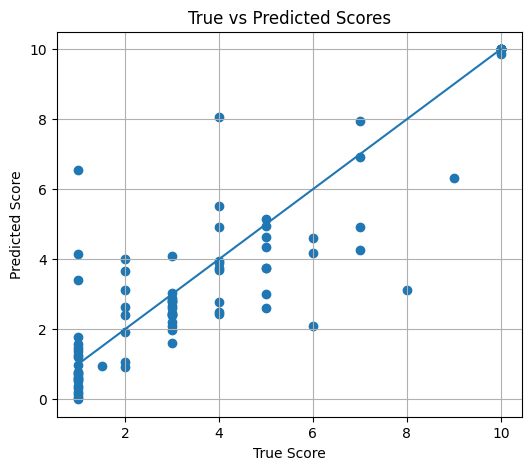

In [72]:
# =========================
# 19. TRUE VS PREDICTED SCATTER PLOT
# =========================

plt.figure(figsize=(6, 5))
plt.scatter(y_true, y_pred)

plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("True vs Predicted Scores")

# Ideal line y = x
min_val = min(y_true)
max_val = max(y_true)
plt.plot([min_val, max_val], [min_val, max_val])

plt.grid(True)
plt.show()

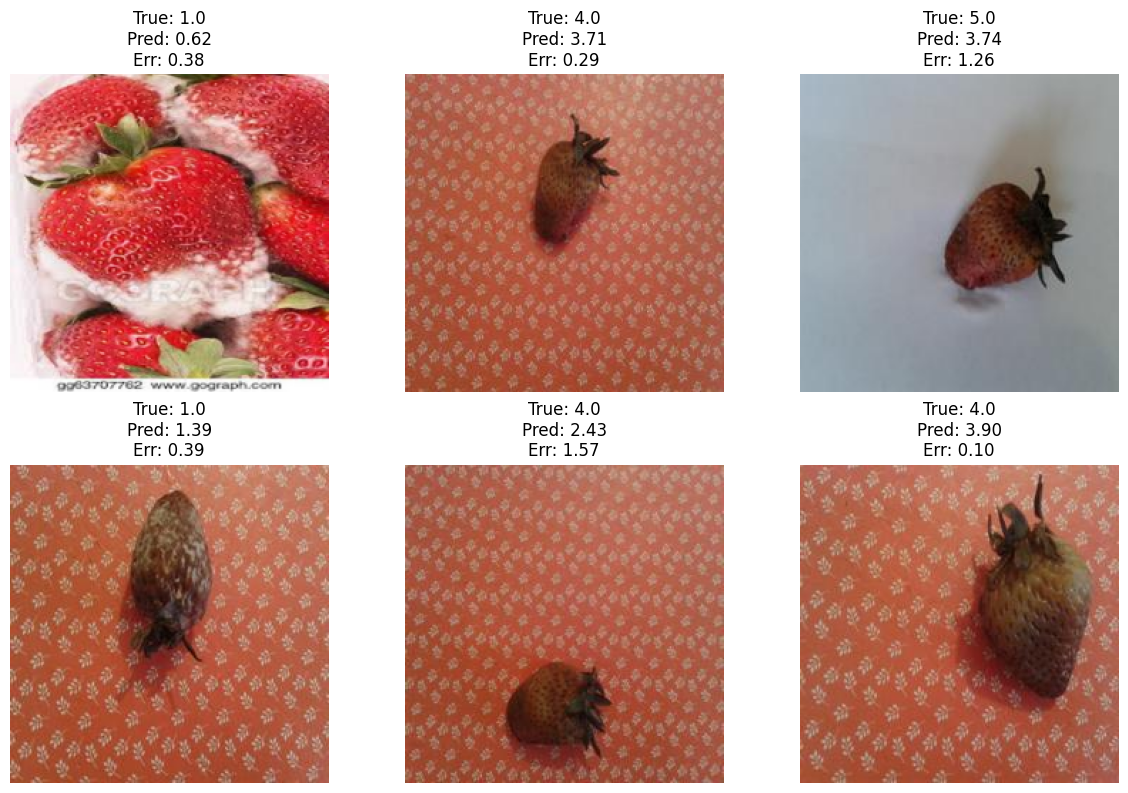

In [73]:
# =========================
# SHOW IMAGES WITH ACTUAL VS PREDICTED
# =========================

import random

model.eval()

num_samples = 6
indices = random.sample(range(len(test_dataset)), num_samples)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    image, true_score = test_dataset[idx]

    # Add batch dimension
    input_img = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(input_img).item()

    # Denormalize (if you normalized scores)
    true_score = true_score.item() * 10
    pred = pred * 10

    error = abs(pred - true_score)

    # Convert tensor to image
    img_np = image.permute(1, 2, 0).cpu().numpy()

    plt.subplot(2, 3, i+1)
    plt.imshow(img_np)
    plt.title(f"True: {true_score:.1f}\nPred: {pred:.2f}\nErr: {error:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

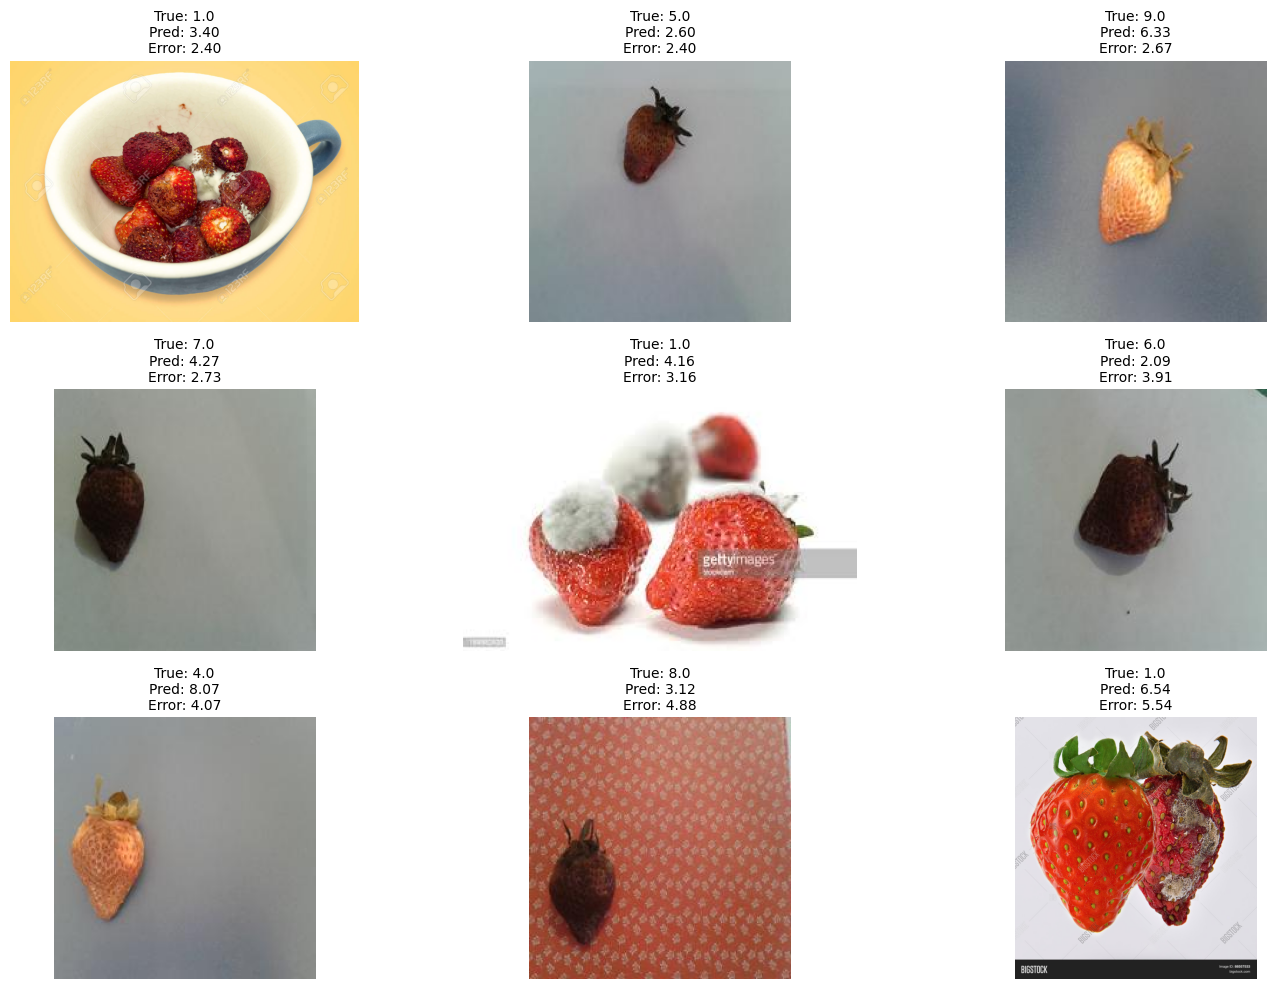

In [74]:
# =========================
# 20. SHOW WORST PREDICTIONS
# =========================

errors = np.abs(np.array(y_true) - np.array(y_pred))
worst_indices = np.argsort(errors)[-9:]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(worst_indices):
    img_name = test_df.iloc[idx][IMAGE_COL]
    img_path = os.path.join(IMAGE_FOLDER, img_name)

    image = Image.open(img_path).convert("RGB")

    true_score = y_true[idx]
    pred_score = y_pred[idx]
    error = abs(true_score - pred_score)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"True: {true_score:.1f}\nPred: {pred_score:.2f}\nError: {error:.2f}",
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()